In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import keras_tuner as kt

In [2]:
#load the datasets
traffic1 = pd.read_csv("C:\\Users\\vinit\\Downloads\\Deep Learning ANN Module\\Project\\archive\\Traffic.csv")
traffic2 = pd.read_csv("C:\\Users\\vinit\\Downloads\\Deep Learning ANN Module\\Project\\archive\\TrafficTwoMonth.csv")

In [3]:
print("Traffic1:", traffic1.shape)
print("Traffic2:", traffic2.shape)

Traffic1: (2976, 9)
Traffic2: (5952, 9)


In [4]:
# Merge Datasets
df = pd.concat([traffic1, traffic2], ignore_index=True)
print("Combined:", df.shape)

Combined: (8928, 9)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8928 entries, 0 to 8927
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               8928 non-null   object
 1   Date               8928 non-null   int64 
 2   Day of the week    8928 non-null   object
 3   CarCount           8928 non-null   int64 
 4   BikeCount          8928 non-null   int64 
 5   BusCount           8928 non-null   int64 
 6   TruckCount         8928 non-null   int64 
 7   Total              8928 non-null   int64 
 8   Traffic Situation  8928 non-null   object
dtypes: int64(6), object(3)
memory usage: 627.9+ KB


In [6]:
df.describe()

,Date,CarCount,BikeCount,BusCount,TruckCount,Total
count,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000,8928.000000
mean,16.000000,66.525986,13.080085,13.701837,17.539203,110.847110
std,8.944773,45.142975,12.059836,13.187748,10.963233,57.474554
min,1.000000,5.000000,0.000000,0.000000,0.000000,21.000000
25%,8.000000,19.000000,4.000000,1.000000,9.000000,55.000000
50%,16.000000,63.000000,10.000000,11.000000,16.000000,105.000000
75%,24.000000,104.000000,20.000000,22.000000,26.000000,157.000000
max,31.000000,180.000000,70.000000,50.000000,60.000000,279.000000


In [7]:
# Checking null values
df.isnull().sum()

Time                 0
Date                 0
Day of the week      0
CarCount             0
BikeCount            0
BusCount             0
TruckCount           0
Total                0
Traffic Situation    0
dtype: int64

In [8]:
# Identifying duplicates rows
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 2604


In [9]:
# Removing duplicates
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(6324, 9)

In [11]:
df.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal


In [12]:
df['Traffic Situation'].value_counts()

Traffic Situation
normal    3858
heavy     1137
low        834
high       495
Name: count, dtype: int64

##### Initial Observation
- The dataset contains 8928 rows and 9 columns.
- There are no missing values in the dataset.
- The dataset contains 2604 duplicate rows, which should be removed to avoid bias in model training.
- The target variable (Traffic Situation) has four classes:
    - Low
    - Normal
    - Heavy
    - High
- The dataset appears to be imbalanced, with the 'normal' class dominating compared to others.
- This class imbalance can be handled during model training using techniques such as SMOTE (Synthetic Minority Oversampling Technique).

**Exploratory Data Analysis**

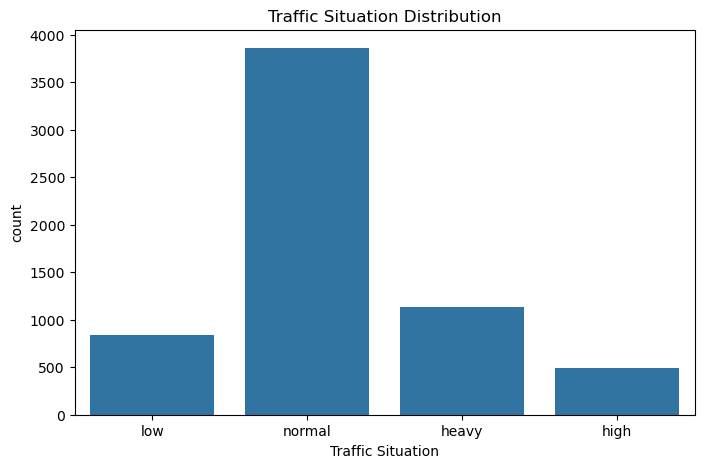

In [13]:
# Traffic Situation Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Traffic Situation', data=df)
plt.title("Traffic Situation Distribution")
plt.show()

##### Traffic Situation Distribution
- The "normal" traffic condition dominates the dataset, indicating most time periods experience moderate traffic.
- "Heavy" traffic occurs less frequently but is still significant.
- "Low" and "high" traffic conditions are relatively rare.
- This suggests a class imbalance, which is important for modeling (may require techniques like SMOTE).

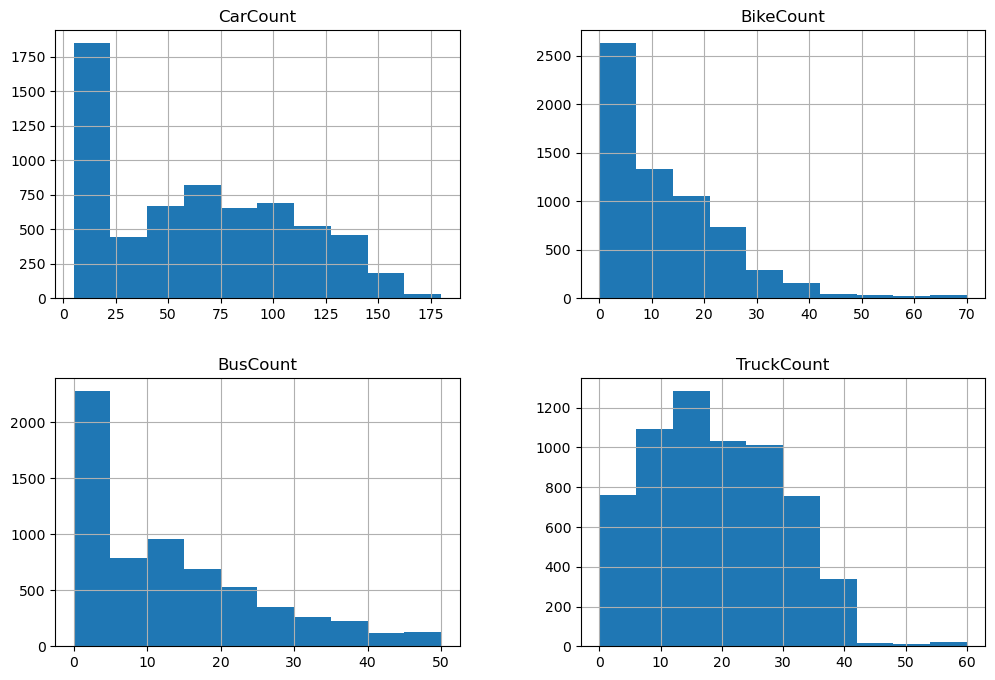

In [14]:
# Vehicle Count Distribution
df[['CarCount','BikeCount','BusCount','TruckCount']].hist(figsize=(12,8))
plt.show()

##### Vehicle Count Distributions
1. Car Count
- Wide distribution ranging from low to very high values.
- Slight right-skewness, indicating occasional high traffic spikes.
- Cars contribute the largest share to total traffic.
2. Bike Count
- Highly right-skewed distribution.
- Most values are concentrated at lower counts, with a few high outliers.
- Indicates bikes are common but usually in smaller numbers.
3. Bus Count
- Strong right skew with most values near zero.
- Buses are infrequent, contributing minimally compared to cars and bikes.
4. Truck Count
- More uniformly distributed compared to other vehicles.
- Moderate variability, with fewer extreme outliers.
- Trucks show a steady presence across time.

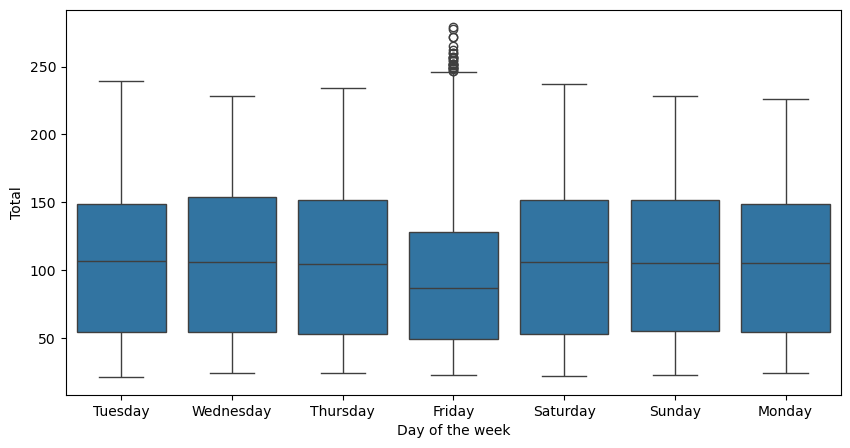

In [15]:
# Traffic vs Day of Week
plt.figure(figsize=(10,5))
sns.boxplot(x='Day of the week', y='Total', data=df)
plt.show()

##### Traffic by Day of the Week
- Traffic distribution is fairly consistent across all days.
- Slight variations exist, but no major spikes or drops on specific days.
- Presence of outliers (especially on Friday) indicates occasional unusually high traffic.
- Suggests day of the week is not a strong standalone predictor.

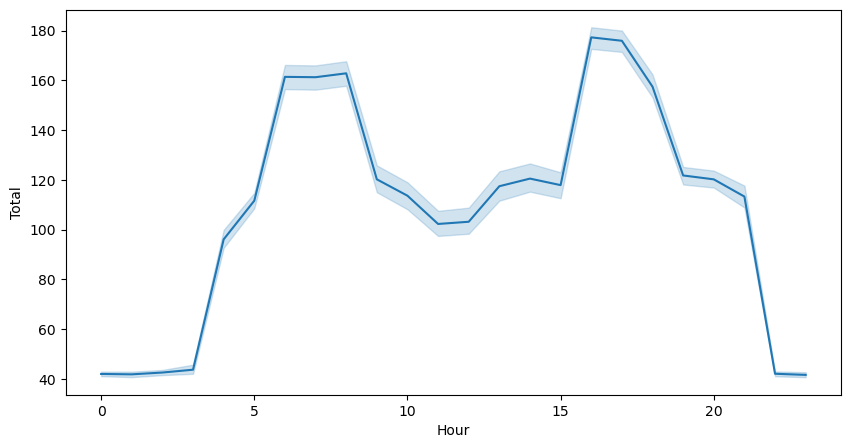

In [16]:
# Traffic Pattern Across Time
df['Hour'] = pd.to_datetime(df['Time'], format='%I:%M:%S %p').dt.hour
plt.figure(figsize=(10,5))
sns.lineplot(x='Hour', y='Total', data=df)
plt.show()

##### Hourly Traffic Trends
- Clear peak hours observed:
   - Morning peak: 7 AM – 9 AM
   - Evening peak: 4 PM – 6 PM
- Traffic is lowest during late night and early morning (12 AM – 4 AM).
- Gradual increase from early morning to peak, followed by decline.
- This shows a strong time-based pattern (rush hours).

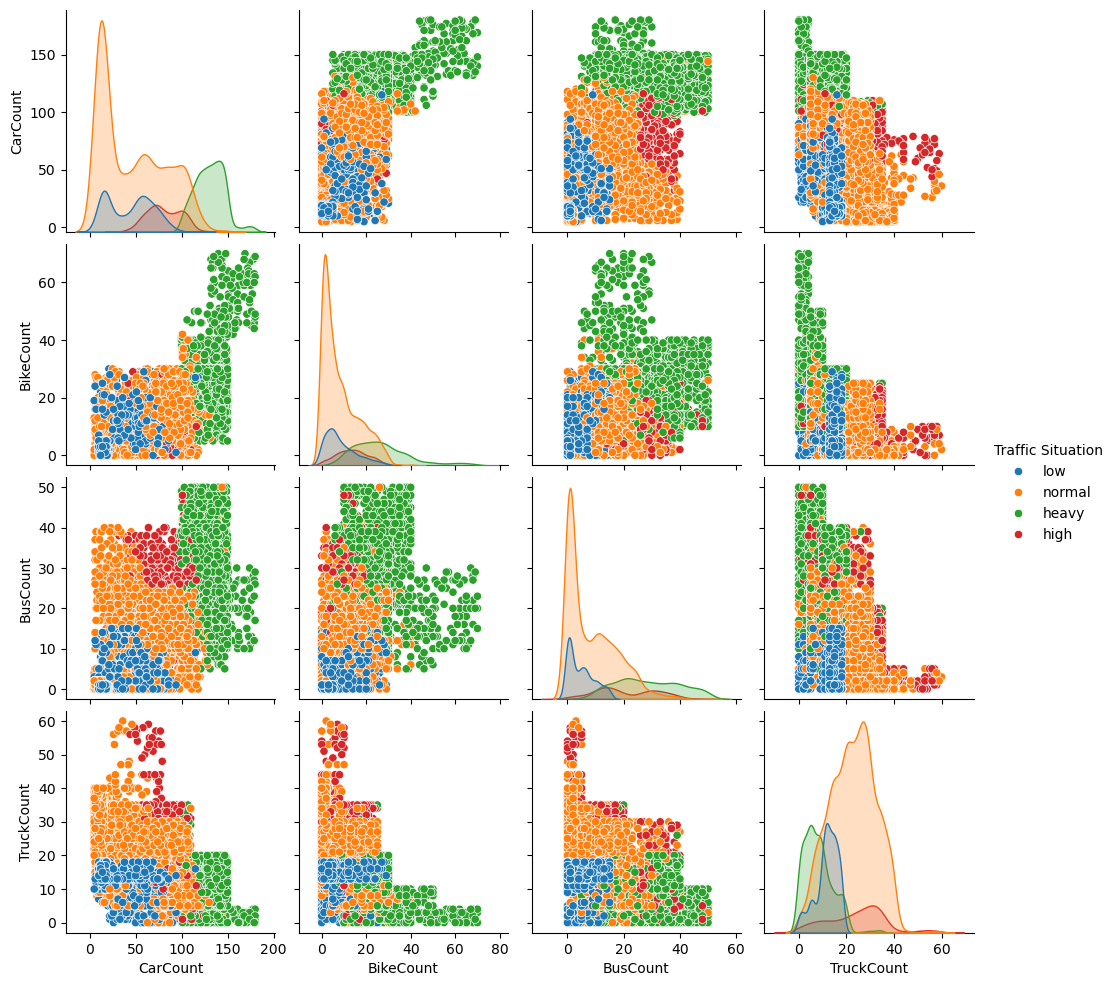

In [17]:
# Vehicle Mix by Traffic Situation
sns.pairplot(df, hue='Traffic Situation', vars=['CarCount','BikeCount','BusCount','TruckCount'])
plt.show()

##### Vehicle Mix by Traffic Situation
- Heavy Traffic (Green): Usually happens when there are a lot of cars and bikes on the road at the same time.
- High Traffic (Red): This is almost always caused by a high number of trucks, even if other vehicle counts are lower.
- Low/Normal Traffic (Blue/Orange): This occurs when the total number of all vehicles is relatively low.

**Feature Engineering**

In [18]:
# Cyclical Encoding for Hour
df['Time_sin'] = np.sin(2*np.pi*df['Hour']/24)
df['Time_cos'] = np.cos(2*np.pi*df['Hour']/24)

- Converts hour feature into sine and cosine values
- Used for cyclical (circular) features like time
- Helps ML models understand time continuity

In [19]:
# One-hot Encoding for Day of the Week
df = pd.get_dummies(df, columns=['Day of the week'], drop_first=True)

In [20]:
# Vehicle Ratios
df['CarRatio'] = df['CarCount'] / df['Total']
df['BikeRatio'] = df['BikeCount'] / df['Total']
df['BusRatio'] = df['BusCount'] / df['Total']
df['TruckRatio'] = df['TruckCount'] / df['Total']

In [21]:
# Label Encoding Target
le = LabelEncoder()
df['Traffic Situation'] = le.fit_transform(df['Traffic Situation'])

In [22]:
# Drop unnecessary columns
df.drop(['Date','Time','Total'], axis=1, inplace=True)

In [23]:
# Splitting Features & Target
X = df.drop('Traffic Situation', axis=1)
y = df['Traffic Situation']

In [24]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [25]:
# Handle Imbalanced Data
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [26]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Model Building**

In [27]:
# Get number of unique classes in the target variable (y_train)
num_classes = len(np.unique(y_train))

# Convert training labels into one-hot encoded format
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

In [28]:
# ANN Model
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))

# Input + Hidden Layers
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(y_train_cat.shape[1], activation='softmax'))

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,364 (13.14 KB)

 Trainable params: 3,364 (13.14 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Model training
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10,  # stop if val_loss doesn’t improve for 10 epochs
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train_cat,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7782 - loss: 0.5619 - val_accuracy: 0.4432 - val_loss: 0.9646
Epoch 2/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9063 - loss: 0.2529 - val_accuracy: 0.7228 - val_loss: 0.5647
Epoch 3/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9243 - loss: 0.1999 - val_accuracy: 0.7467 - val_loss: 0.5306
Epoch 4/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9280 - loss: 0.1797 - val_accuracy: 0.7794 - val_loss: 0.4805
Epoch 5/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9371 - loss: 0.1631 - val_accuracy: 0.7079 - val_loss: 0.6207
Epoch 6/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9386 - loss: 0.1551 - val_accuracy: 0.8444 - val_loss: 0.3590
Epoch 7/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9430 - loss: 0.1482 - val_accuracy: 0.6937 - val_loss: 0.6576
Epoch 8/100
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9453 - loss: 0.1433 - val_accu

**Model Evaluation**

In [30]:
# Evaluate
loss, acc = model.evaluate(X_test, y_test_cat)
print("ANN Test Accuracy:", acc)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8862 - loss: 0.2576
ANN Test Accuracy: 0.8861660361289978


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       220
           1       0.62      0.78      0.69        97
           2       0.75      0.90      0.82       183
           3       0.95      0.86      0.90       765

    accuracy                           0.89      1265
   macro avg       0.82      0.89      0.85      1265
weighted avg       0.90      0.89      0.89      1265



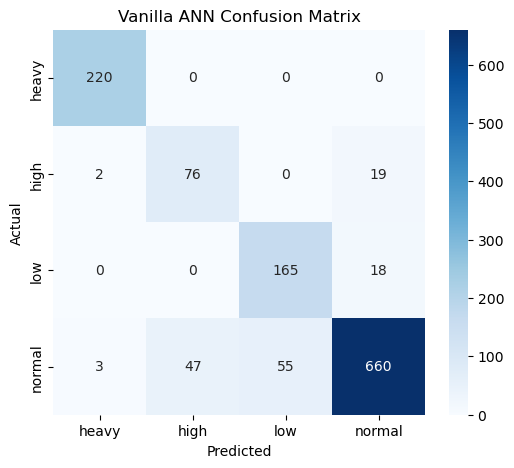

In [31]:
# Confusion Matrix & Report
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Vanilla ANN Confusion Matrix")
plt.show()

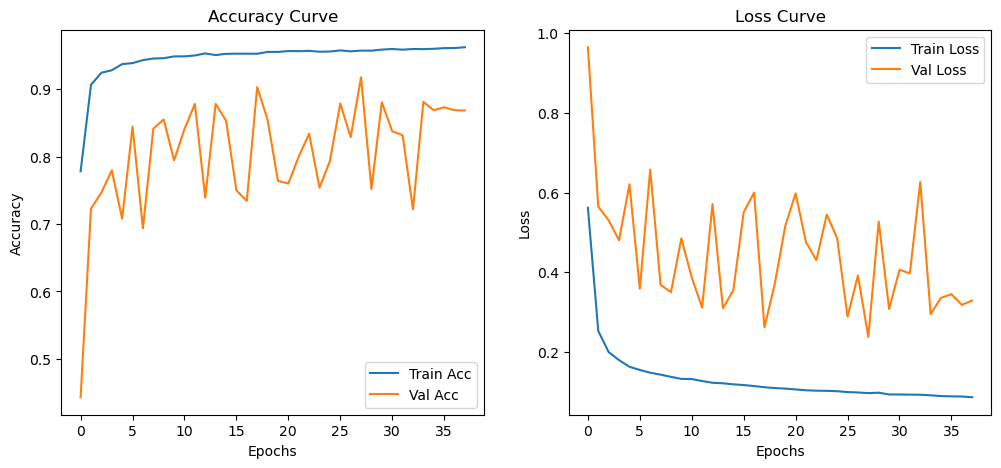

In [32]:
# Accuracy & Loss Curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**ML Model Comparison**

In [33]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.850592885375494
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       220
           1       0.62      0.68      0.65        97
           2       0.70      0.73      0.72       183
           3       0.89      0.86      0.88       765

    accuracy                           0.85      1265
   macro avg       0.79      0.81      0.80      1265
weighted avg       0.85      0.85      0.85      1265



In [34]:
# XGBoost
xgb_model = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8608695652173913
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       220
           1       0.65      0.69      0.67        97
           2       0.72      0.73      0.72       183
           3       0.89      0.88      0.89       765

    accuracy                           0.86      1265
   macro avg       0.81      0.82      0.81      1265
weighted avg       0.86      0.86      0.86      1265



**ANN Fine-Tuning (Keras Tuner)**

In [35]:
# Keras-tuning
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))

    model.add(Dense(hp.Int('units_1', 16, 128, 16), activation='relu'))
    model.add(Dense(hp.Int('units_2', 8, 64, 8), activation='relu'))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=2,
    directory='ann_tuning_v1',
    project_name='traffic_prediction'
)

tuner.search(X_train, y_train, epochs=30, validation_split=0.2)

best_model = tuner.get_best_models(num_models=1)[0]

best_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

test_loss, test_acc = best_model.evaluate(X_test, y_test)
print("Tuned ANN Test Accuracy:", test_acc)

Reloading Tuner from ann_tuning_v1\traffic_prediction\tuner0.json



C:\Users\Public\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8419 - loss: 0.4084
Tuned ANN Test Accuracy: 0.8418972492218018


In [36]:
y_pred = np.argmax(best_model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred))

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

           0       0.99      0.85      0.91       220
           1       0.55      0.73      0.63        97
           2       0.69      0.82      0.75       183
           3       0.90      0.86      0.88       765

    accuracy                           0.84      1265
   macro avg       0.78      0.82      0.79      1265
weighted avg       0.86      0.84      0.85      1265



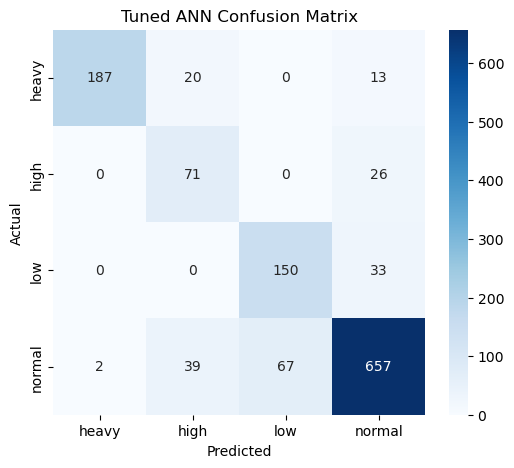

In [37]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned ANN Confusion Matrix")
plt.show()

In [38]:
models = {
    "ANN": acc,
    "Tuned ANN": test_acc,
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "XGBoost": accuracy_score(y_test, y_pred_xgb)
}

best_model_name = max(models, key=models.get)

print("Best Model:", best_model_name)
print("Best Score:", models[best_model_name])

Best Model: ANN
Best Score: 0.8861660361289978


In [39]:
# Saving the best model
model.save("ann_model.keras")

In [40]:
# Saving the scalar 
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [41]:
# Saving label encoder
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

**Conclusion**

In [43]:
print(le.classes_)

['heavy' 'high' 'low' 'normal']


**Project Overview**

This project focused on developing a comprehensive Traffic Situation Prediction system using real-world traffic datasets. The objective was to predict traffic conditions based on vehicle counts, time, and day of the week. The workflow included data preprocessing, exploratory data analysis (EDA), feature engineering, model development, evaluation, hyperparameter tuning, and model comparison using both machine learning and deep learning approaches.

**Data Understanding and Preprocessing**

##### Datasets Used: 
- Two traffic datasets (Traffic.csv and TrafficTwoMonth.csv) containing:
     - Car, Bike, Bus, Truck counts
     - Total traffic
     - Time
     - Day of the week

##### Key Observations:
- Combined dataset contained duplicate rows, which were removed to ensure data quality.
- No significant missing values were observed.
- The target variable (Traffic Situation) showed class imbalance, requiring oversampling techniques.

Data Preprocessing Steps:
- Duplicate rows removed
- Label encoding applied to target variable (Traffic Situation)
- One-hot encoding applied to categorical feature (Day of the Week)
- Numerical features scaled using StandardScaler
- SMOTE applied to handle class imbalance in training data
  
**Exploratory Data Analysis (EDA)**
1. Traffic Situation Distribution:
Count plot revealed class imbalance across traffic categories
2. Vehicle Count Distribution:
Histograms showed skewed distributions for Car, Bike, Bus, and Truck counts
Indicated peak traffic behavior during specific time periods
3. Total Traffic Analysis:
Distribution of total traffic showed high variability across time and days
4. Traffic vs Day of Week:
Boxplots indicated higher traffic during weekdays compared to weekends
5. Traffic Pattern Across Time:
Line plot (Hour vs Total traffic) showed morning and evening peak congestion
6. Correlation Analysis:
Strong correlation observed between:
Total traffic
Individual vehicle counts
7. Vehicle Mix by Traffic Situation:
Different traffic classes showed distinct vehicle composition patterns

##### Key EDA Insight:

Traffic patterns are strongly influenced by time, day of week, and vehicle composition, validating their use as predictive features.

**Feature Engineering**

Cyclical Encoding for Time:
- Used sin and cos transformations to represent cyclical nature of hours:
    Time_sin, Time_cos

Vehicle Ratio Features:
- Created normalized features:
   CarRatio, BikeRatio, BusRatio, TruckRatio

Outcome:

Feature engineering improved model understanding of relative traffic composition rather than raw counts.

**Model Development and Evaluation**
1. ANN
Architecture:
- 2 hidden layers (64, 32 neurons)
- ReLU activation
- Softmax output layer
- Training: Early stopping applied (patience = 10)
- Performance: Test Accuracy: ~0.8870
- Observation: Captured non-linear relationships effectively and Performed well on majority classes but struggled slightly with minority classes

2. Random Forest
- Performance: Accuracy: ~0.8538
- Observation: Robust to noise and scaling
- Performed well on dominant classes
- Limited performance on minority classes
  
3. XGBoost
- Performance: Accuracy: ~0.8632
Observation:
- Captured complex feature interactions effectively
- Strong generalization performance
- Better balance between precision and recall compared to Random Forest
  
4. ANN with Hyperparameter Tuning (Keras Tuner)
Optimization:
- Tuned hidden layer units
- Tuned learning rate
- Used Random Search strategy
- Performance: Test Accuracy: ~0.8767
Observation:
- Improved generalization compared to baseline ANN
- Reduced manual tuning effort significantly
  
**Comparative Model Performance**

Model - Test Accuracy

ANN	       -       0.8870

Tuned ANN	-      0.8767

Random Forest  -	0.8538

XGBoost	   -       0.8632

**Best Model**
- Vanilla ANN achieved the highest test accuracy (0.8870)
- Recommended for deployment when using deep learning approach
- XGBoost is a strong alternative due to robustness and interpretability
  
**Final Insight**
- SMOTE improved minority class predictions significantly
- ANN models captured complex patterns better than traditional ML models
- Tree-based models provided strong baseline performance with interpretability
  
**Model Saving**
- Final trained ANN model, scaler, encoding saved as:
    - ann_model.keras
    - scaler.pkl
    - label_encoder.pkl
- Can be used for real-time traffic situation prediction

**Model Deployment**

  
**Business Impact**

This system enables:
- Prediction of traffic congestion in advance
- Optimization of traffic signal timings
- Improved urban traffic management
- Better commuter experience
- Support for smart city planning initiatives